In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.features import cycle_day_month
from src._xgboost import search_params
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame, start_date: str):
    df = data.copy()
    df = df.asfreq('D')
    df = cycle_day_month(df)
    
    start_date = pd.to_datetime(start_date)
    df['days_from_start'] = (df['Дата'] - start_date).dt.days
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(X_train, y_true, y_pred, title="Прогноз vs Истинные значения"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    ax1.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.set_title('Тестовый период')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.plot(X_train.index, X_train.values, 
             label='Исторические (X_train)', color='green', linewidth=1.5, alpha=0.7)
    ax2.plot(y_true.index, y_true.values, 
             label='Истинные (тест)', color='blue', linewidth=1.5)
    ax2.plot(y_pred.index, y_pred.values, 
             label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Дата')
    ax2.set_ylabel('Значение')
    ax2.set_title('Полный период (история + тест)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def show_results(model, df_train_full, df_test, target_col, exog_cols):
    y_pred = model.predict(
                steps=len(df_test),
                exog=df_test[exog_cols]
            )

    rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
    print(f'RMSE на тесте = {rmse}')

    plot_forecast(df_train_full[target_col], df_test[target_col], y_pred)

In [4]:
start_date = '2020-11-27'

df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full, start_date)
df_train = process_data(df_train, start_date)
df_val = process_data(df_val, start_date)
df_test = process_data(df_test, start_date)

Глубина 0

In [6]:
depth = 0
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [ ]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 18:52:54,348] A new study created in memory with name: no-name-b4b0412a-9c20-44fb-a7be-1b463aebd191
[I 2026-05-10 18:52:54,720] Trial 0 finished with value: 6.5150071996295456 and parameters: {'lags': 4, 'n_estimators': 633, 'learning_rate': 0.0027288332060694835, 'max_depth': 2, 'subsample': 0.6381049025318486, 'colsample_bytree': 0.7267584628783035, 'colsample_bylevel': 0.9512964837035076, 'colsample_bynode': 0.6630601386121319, 'reg_alpha': 0.0003347898257601695, 'reg_lambda': 0.45850635744545704, 'gamma': 2.1780241083455167, 'min_child_weight': 1, 'max_delta_step': 13}. Best is trial 0 with value: 6.5150071996295456.
[I 2026-05-10 18:52:55,034] Trial 1 finished with value: 7.454552461407626 and parameters: {'lags': 3, 'n_estimators': 295, 'learning_rate': 0.0029535104668994483, 'max_depth': 5, 'subsample': 0.44444342343494114, 'colsample_bytree': 0.49747526249518936, 'colsample_bylevel': 0.7504408732731684, 'colsample_bynode': 0.8442349612566826, 'reg_alpha': 0.070660

Лучшие параметры = {'lags': 2, 'n_estimators': 603, 'learning_rate': 0.007907569332219333, 'max_depth': 2, 'subsample': 0.9529933230959311, 'colsample_bytree': 0.6975004978656303, 'colsample_bylevel': 0.7605116486340937, 'colsample_bynode': 0.8669756742167041, 'reg_alpha': 4.531200722470567e-05, 'reg_lambda': 0.5499058926205458, 'gamma': 6.100871905487652e-05, 'min_child_weight': 8, 'max_delta_step': 8}
Лучший RMSE score = 3.4930786652629036


C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:2864: UserWarning: [15:41:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "lags" } are not used.

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


RMSE на тесте = 2.9306067299959264


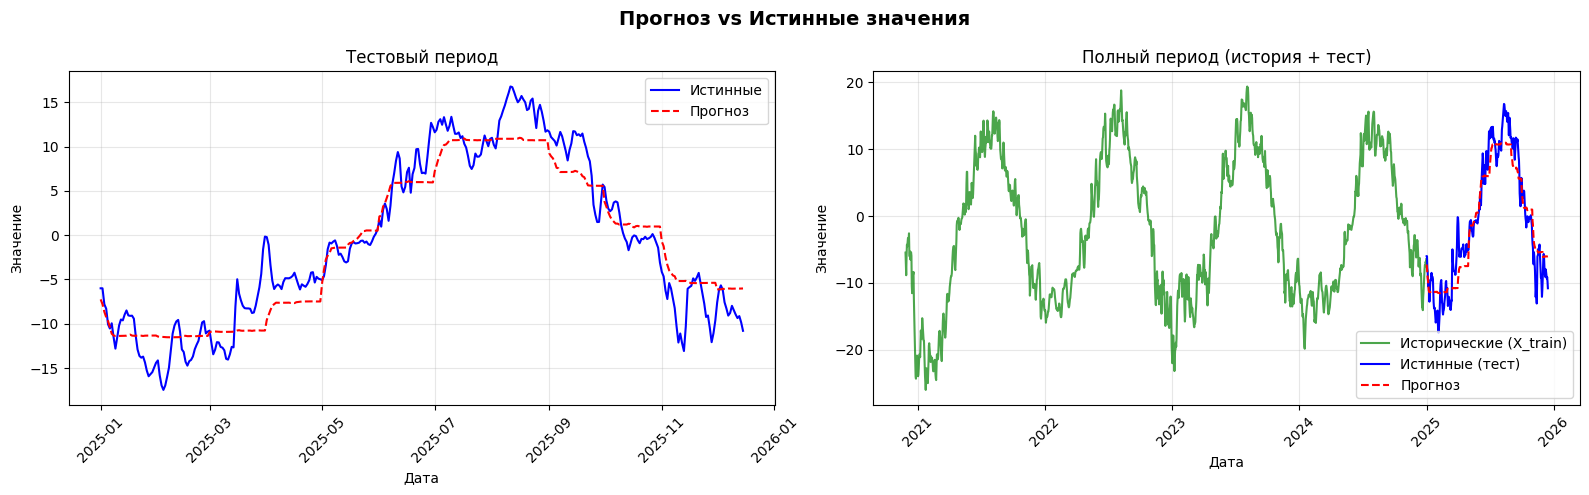

,feature,importance
3,Месяц_cos,0.308746
0,lag_1,0.302251
1,lag_2,0.251187
6,days_from_start,0.078346
2,Месяц_sin,0.054339
4,День_sin,0.003992
5,День_cos,0.001138


In [7]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 5

In [8]:
depth = 5
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [ ]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 18:53:10,109] A new study created in memory with name: no-name-8a8c655a-1a00-4a7c-8fe0-ccaa1f8755ff
[I 2026-05-10 18:53:10,453] Trial 0 finished with value: 1.2844865546755575 and parameters: {'lags': 2, 'n_estimators': 525, 'learning_rate': 0.028369064754915952, 'max_depth': 9, 'subsample': 0.7653026780294769, 'colsample_bytree': 0.907503693435626, 'colsample_bylevel': 0.9177651538948463, 'colsample_bynode': 0.4404301379689783, 'reg_alpha': 1.2612804535795774, 'reg_lambda': 0.0274869458836887, 'gamma': 0.00042253056403227375, 'min_child_weight': 15, 'max_delta_step': 18}. Best is trial 0 with value: 1.2844865546755575.
[I 2026-05-10 18:53:10,663] Trial 1 finished with value: 2.041850799706542 and parameters: {'lags': 2, 'n_estimators': 339, 'learning_rate': 0.0007949544427220627, 'max_depth': 4, 'subsample': 0.9356634921537003, 'colsample_bytree': 0.8975534501229171, 'colsample_bylevel': 0.46651553970711135, 'colsample_bynode': 0.5339124280634742, 'reg_alpha': 0.05989316

Лучшие параметры = {'lags': 1, 'n_estimators': 808, 'learning_rate': 0.01763750782709503, 'max_depth': 9, 'subsample': 0.7883512380272375, 'colsample_bytree': 0.8966192558879225, 'colsample_bylevel': 0.9011988139164099, 'colsample_bynode': 0.9746396278739065, 'reg_alpha': 3.5567911265954546, 'reg_lambda': 0.007931888348285029, 'gamma': 0.057339485513491675, 'min_child_weight': 3, 'max_delta_step': 11}
Лучший RMSE score = 0.8988459610711599


C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:2864: UserWarning: [15:41:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "lags" } are not used.

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


RMSE на тесте = 0.5109657318805885


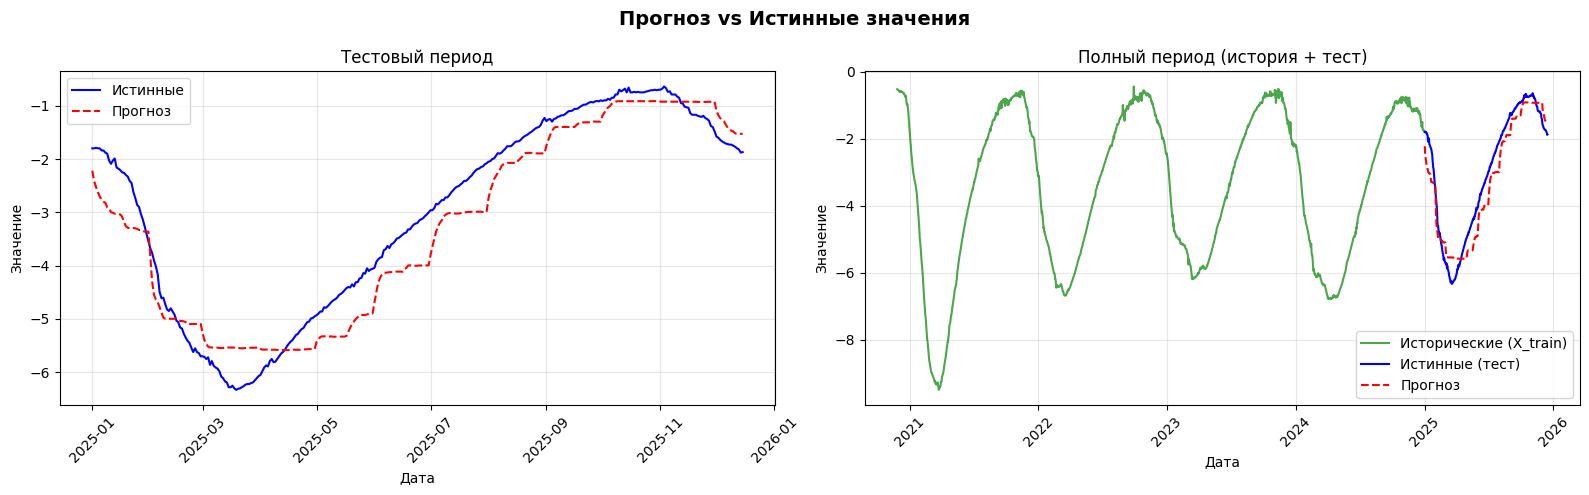

,feature,importance
1,Месяц_sin,0.667272
0,lag_1,0.191748
2,Месяц_cos,0.066915
5,days_from_start,0.061063
3,День_sin,0.010165
4,День_cos,0.002837


In [9]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 10

In [10]:
depth = 10
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [ ]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 18:53:30,310] A new study created in memory with name: no-name-9b585b5f-9a24-4caa-a59c-04019a611e88
[I 2026-05-10 18:53:30,511] Trial 0 finished with value: 0.7382177133274145 and parameters: {'lags': 2, 'n_estimators': 476, 'learning_rate': 0.003903847060302821, 'max_depth': 6, 'subsample': 0.534094589559914, 'colsample_bytree': 0.6767358147618275, 'colsample_bylevel': 0.9491154944569469, 'colsample_bynode': 0.4413098493863572, 'reg_alpha': 3.3497135379343552, 'reg_lambda': 0.004994813775780448, 'gamma': 0.001585762635883078, 'min_child_weight': 2, 'max_delta_step': 7}. Best is trial 0 with value: 0.7382177133274145.
[I 2026-05-10 18:53:30,680] Trial 1 finished with value: 0.8506798688719195 and parameters: {'lags': 2, 'n_estimators': 620, 'learning_rate': 0.0020196442434941898, 'max_depth': 3, 'subsample': 0.9705499908947153, 'colsample_bytree': 0.6529591245727056, 'colsample_bylevel': 0.7487763499810556, 'colsample_bynode': 0.578621778565368, 'reg_alpha': 0.00276525770

Лучшие параметры = {'lags': 2, 'n_estimators': 294, 'learning_rate': 0.10166716271903116, 'max_depth': 1, 'subsample': 0.7757996498678303, 'colsample_bytree': 0.4748189213233232, 'colsample_bylevel': 0.7695345446348824, 'colsample_bynode': 0.6855961799083972, 'reg_alpha': 5.203126429987796, 'reg_lambda': 0.01633577371884538, 'gamma': 4.944291441931432e-05, 'min_child_weight': 4, 'max_delta_step': 19}
Лучший RMSE score = 0.5045359900686958


C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:2864: UserWarning: [15:41:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "lags" } are not used.

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


RMSE на тесте = 0.39905521573784747


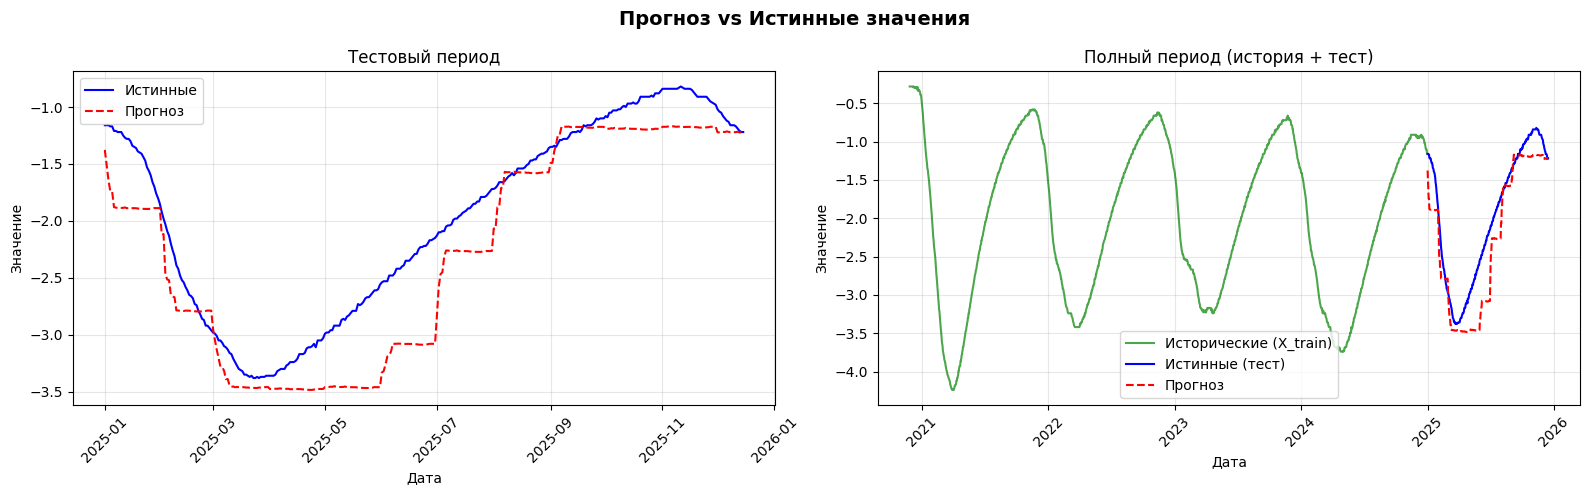

,feature,importance
1,lag_2,0.481421
0,lag_1,0.239493
2,Месяц_sin,0.230041
6,days_from_start,0.040038
3,Месяц_cos,0.006483
4,День_sin,0.001730
5,День_cos,0.000794


In [11]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

In [16]:
best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
best_model.fit(
            y=df_train_full[target_col],
            exog=df_train_full[exog_cols],
        )

joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v1_10']